In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [2]:
from src.transforms import trainval_transforms, revert_normalization, revert_standardization
from src.dataset import ImageDataset
import torch

annot_path = Path("../data/preprocessed/trainval/annotations.csv")
img_dir = Path("../data/preprocessed/trainval/images")

# test dataset without transforms
dataset = ImageDataset(annot_path, img_dir, transform=trainval_transforms)

In [3]:
image, labels = next(iter(dataset))
obj_coords = []
obj_coords_tensors = []

In [4]:
revert_standardization(image)
image = revert_normalization(image)

In [5]:
from src.utilities import convert_xywh_coordinates

for i in range(7):
    for j in range(7):
        coord = labels[i][j][20:24]
        
        if torch.any(coord):
            obj_coords.append(
                convert_xywh_coordinates(coord, i, j, True)
            )
            obj_coords_tensors.append(
                convert_xywh_coordinates(coord, i, j, False)
            )

In [6]:
obj_coords

[(124, 111, 140, 131),
 (108, 116, 132, 178),
 (2, 146, 30, 224),
 (74, 158, 114, 222),
 (118, 126, 144, 202)]

In [7]:
labels = ["1", "2", "3", "4", "5"]

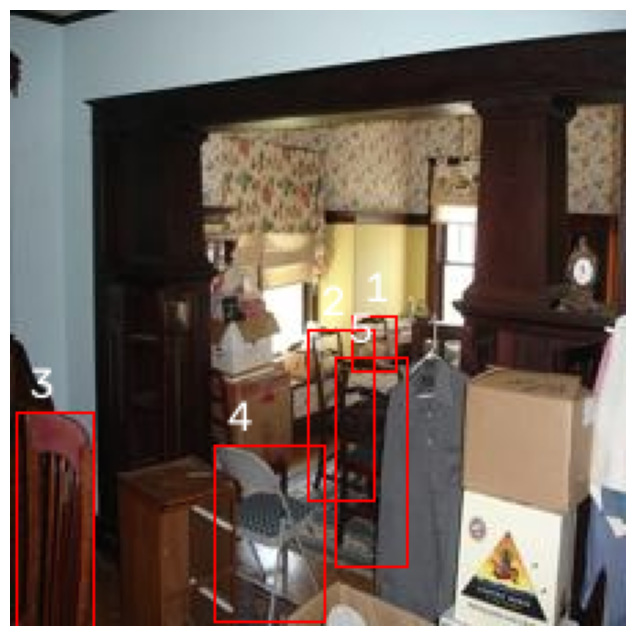

In [8]:
from matplotlib import pyplot as plt
from src.visualization import draw_rectangles

fig, ax = plt.subplots(1, figsize=(8, 8))

image = draw_rectangles(image, obj_coords, labels)

ax.imshow(image)
ax.axis(False)

plt.show()

In [9]:
from src.utilities import IoU

# Test first on completely matched boxes
IoU_1 = IoU(obj_coords_tensors[1], obj_coords_tensors[1])

# Test second on completely unmatched boxes
IoU_2 = IoU(obj_coords_tensors[2], obj_coords_tensors[3])

# Test third on slightly matched boxes
IoU_3 = IoU(obj_coords_tensors[1], obj_coords_tensors[3])
IoU_4 = IoU(obj_coords_tensors[1], obj_coords_tensors[0])
IoU_5 = IoU(obj_coords_tensors[1], obj_coords_tensors[4])

print(IoU_1, IoU_2, IoU_3, IoU_4, IoU_5)

tensor(1.) tensor(0.) tensor(0.0294) tensor(0.0726) tensor(0.2716)


In [10]:
from src.utilities import objects_in_target

objects = objects_in_target(labels)
objects

IndexError: string index out of range